Loading data from: /home/mariopasc/Python/Datasets/EEG/timeseries/processed/zerolag/CT_UP_preprocess_2.npz


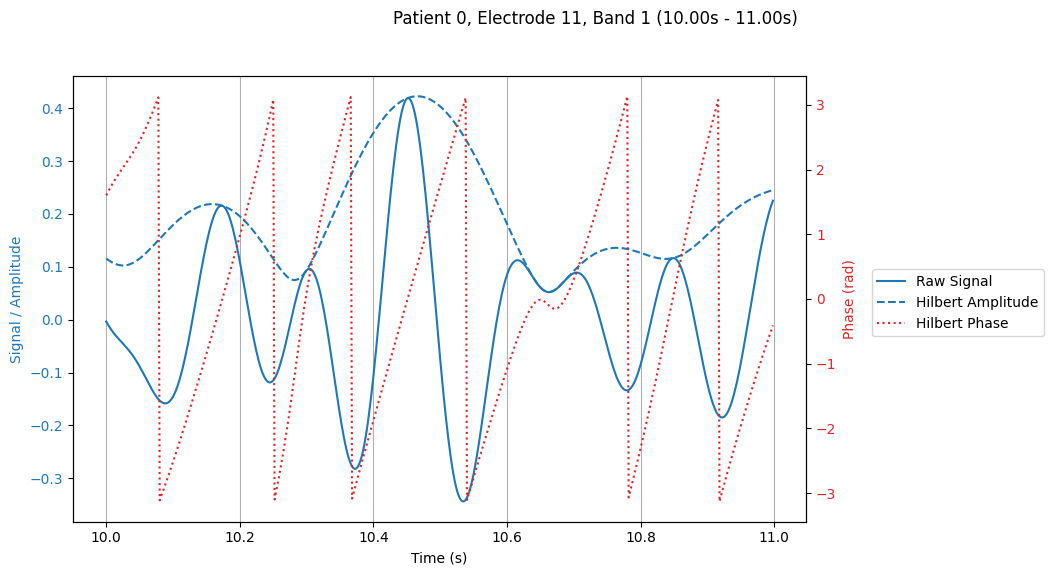

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Assuming pyddeeg is installed and accessible
from pyddeeg.preprocessing.tools.hilbert_tr import hilbert_transform

# --- Data Loading ---
ZEROLAG = "/home/mariopasc/Python/Datasets/EEG/timeseries/processed/zerolag"
STIMULI = 2
DIRECTION = "UP"
FS = 500 # Sampling frequency in Hz

files = [f for f in os.listdir(ZEROLAG) if DIRECTION in f and f"_{str(STIMULI)}.npz" in f]

if not files:
    raise FileNotFoundError("No matching data files found.")

file_path = os.path.join(ZEROLAG, files[0])
print(f"Loading data from: {file_path}")
data = np.load(file_path, allow_pickle=True)["data"] # Shape: (34, 32, 68000, 5)

# --- User Selections ---
patient_idx = 0
electrode_idx = 11
band_idx = 1       # Select the frequency band index (0-4)
start_time = 10.0  # Start time of the window in seconds
end_time = 11    # End time of the window in seconds

# --- Select Data for the chosen band ---
# Shape becomes (68000,)
selected_signal = data[patient_idx, electrode_idx, :, band_idx]

# --- Apply Hilbert Transform ---
# Unwrap phase for easier visualization within a window
phase, amplitude = hilbert_transform(selected_signal, fs=FS, band=None, unwrap=False) # Changed unwrap to False

# --- Time Windowing ---
time_full = np.arange(selected_signal.shape[0]) / FS # Full time vector

# Calculate sample indices for the window
start_sample = int(start_time * FS)
end_sample = int(end_time * FS)

# Ensure indices are within bounds
if start_sample < 0 or end_sample > selected_signal.shape[0] or start_sample >= end_sample:
    raise ValueError(f"Invalid time window: {start_time}s - {end_time}s. Max time: {time_full[-1]:.2f}s")

# Slice data to the selected window
time_window = time_full[start_sample:end_sample]
signal_window = selected_signal[start_sample:end_sample]
amplitude_window = amplitude[start_sample:end_sample]
phase_window = phase[start_sample:end_sample]

# --- Plotting ---
fig, ax1 = plt.subplots(figsize=(12, 6))

color_signal = 'tab:blue'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Signal / Amplitude', color=color_signal)
ax1.plot(time_window, signal_window, color=color_signal, linestyle='-', label=f'Raw Signal ')
ax1.plot(time_window, amplitude_window, color=color_signal, linestyle='--', label=f'Hilbert Amplitude')
ax1.tick_params(axis='y', labelcolor=color_signal)
ax1.grid(True, axis='x') # Grid only on x-axis for clarity

# Instantiate a second axes that shares the same x-axis for phase
ax2 = ax1.twinx()
color_phase = 'tab:red'
ax2.set_ylabel('Phase (rad)', color=color_phase)
ax2.plot(time_window, phase_window, color=color_phase, linestyle=':', label=f'Hilbert Phase ')
ax2.tick_params(axis='y', labelcolor=color_phase)


# ...existing code...
# Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# Place legend outside the plot to the right, vertically centered
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', bbox_to_anchor=(1.08, 0.4))

fig.suptitle(f'Patient {patient_idx}, Electrode {electrode_idx}, Band {band_idx} ({start_time:.2f}s - {end_time:.2f}s)')
# Adjust layout to make space for the legend
plt.tight_layout(rect=[0, 0.03, 0.9, 0.95]) # Reduced right boundary to make space
plt.show()


In [6]:
from pyddeeg.preprocessing.tools.rqa_toolbox import extract_signal_windows, compute_rqa_metrics_for_window, tune_tau_per_window, tune_m_per_window
from pyddeeg.utils.visualize import plot_tau_fnn_attractor

windows = extract_signal_windows(signal=phase, window_size=500)

n_windows = windows.shape[0]
tau_results = tune_tau_per_window(windows, max_lag=120)
taus = np.array([r["best_tau"] for r in tau_results])
m_results = tune_m_per_window(windows, taus=taus, max_dim=12) 
ms = np.array([r["best_m"] for r in m_results])

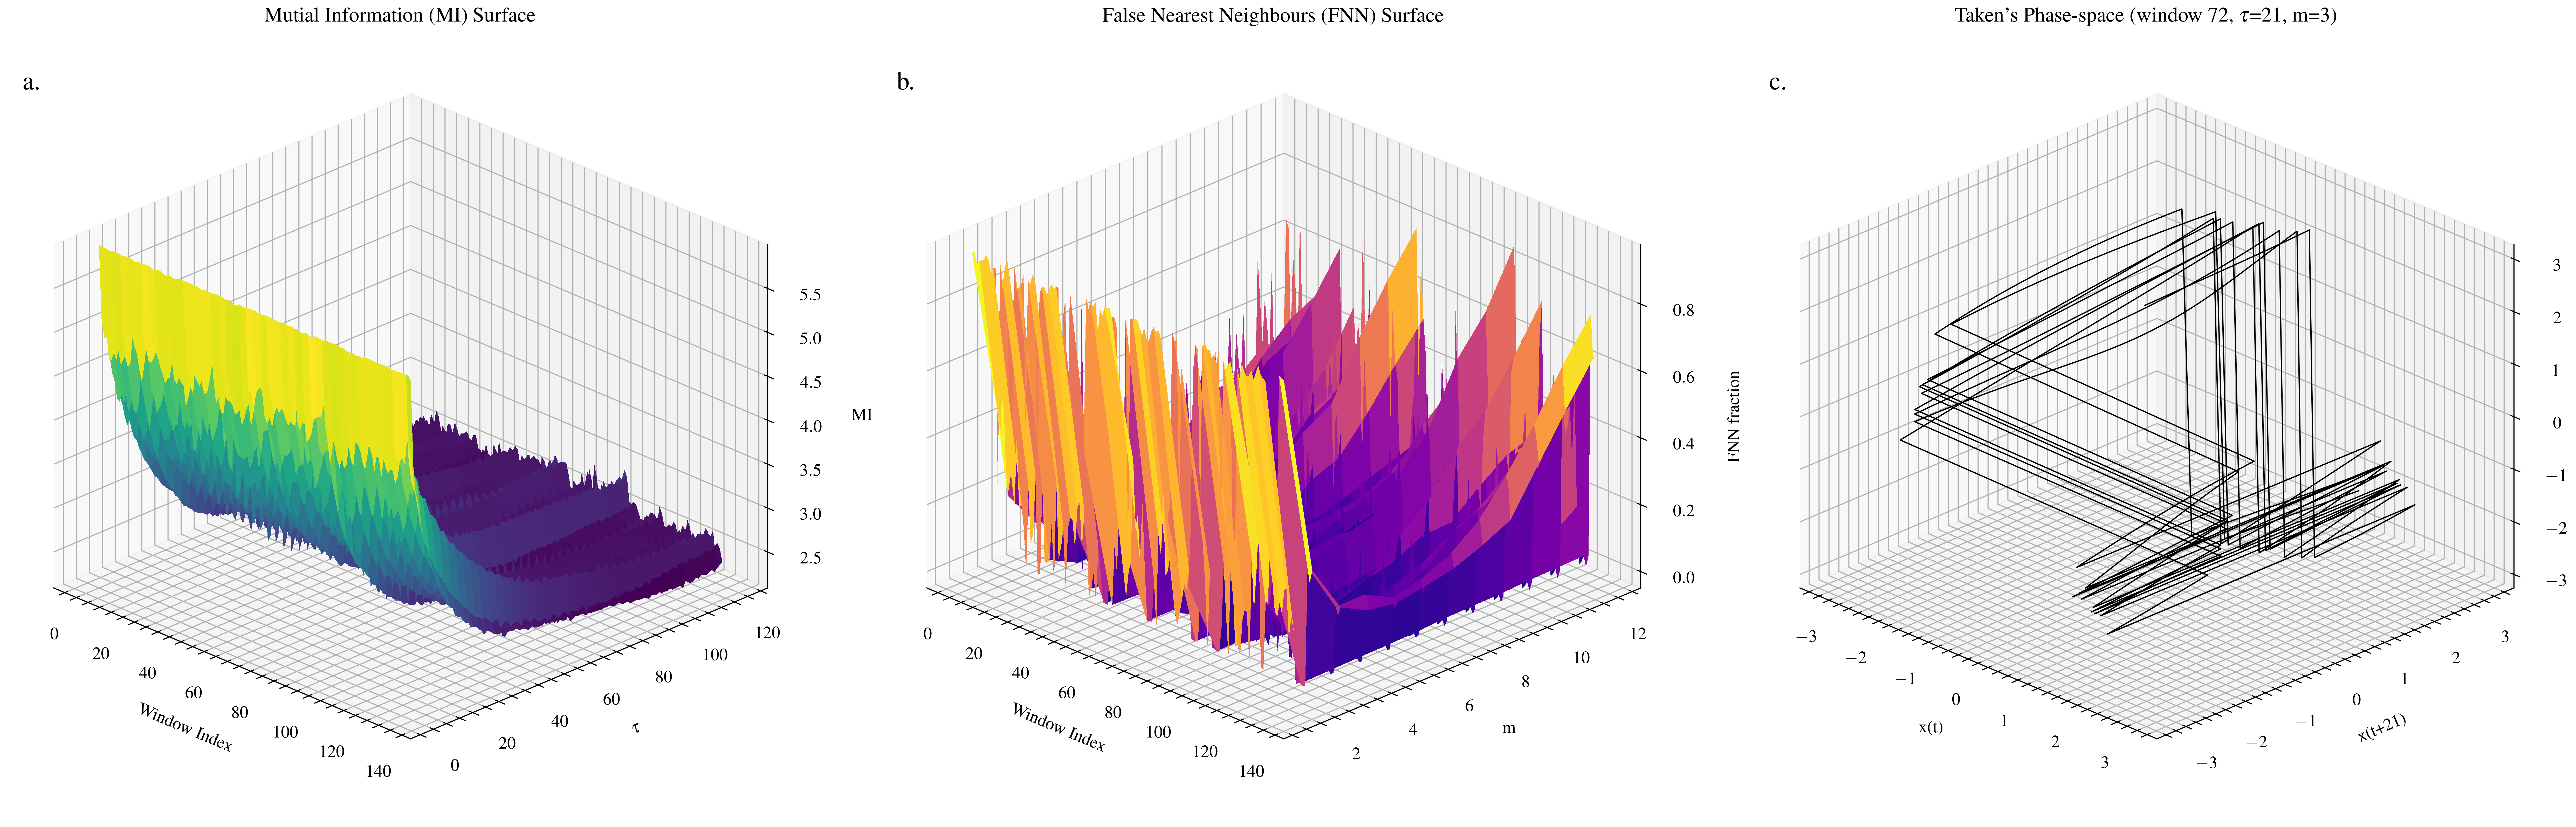

In [5]:
plot_tau_fnn_attractor(tau_results=tau_results, m_results=m_results, windows=windows, elev=25, azim=-45)